# 통계 검정 정리

이 노트북은 성남시 젠트리피케이션 분석에 활용한 주요 변수 간 관계를 상관분석과 가설검정으로 확인한다.

**정리 기준**
- 코드 셀은 수정하지 않고, 분석 흐름을 읽기 쉽도록 마크다운 설명만 정리함.
- 유의수준은 0.05를 기준으로 해석함.
- 각 분석은 변수 설명, 가설, 상관관계 요약, 검정 결과 순서로 정리함.

**분석 항목**
1. 객단가와 신규점포 잔존율
2. 신규기업 수와 폐업 점포 수
3. 신규기업 수와 프랜차이즈 수
4. 단순 통과인구와 유동인구/체류시간
5. 유동인구와 매출건수
6. 유동인구와 매출금액
7. 유동인구와 객단가

In [1]:
import os
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
pd.set_option('display.max_rows', None)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
file_path = 'C:/python_course/final_project/eunbi/data'

In [4]:
df = pd.read_csv(file_path+'/행정동_분기_마스터(최종).csv')

## 1. 객단가와 신규점포 잔존율
**분석 변수**
- 객단가(`avg_ticket`): 고객 1인당 평균 카드 소비금액
- 신규점포 1년 잔존율(`survival_rate_1y`)

In [92]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]

In [93]:
data = df_24_25.groupby(["base_quarter", "adm_dong_nm"]).agg({"avg_ticket": "mean", "survival_rate_1y": "mean"})

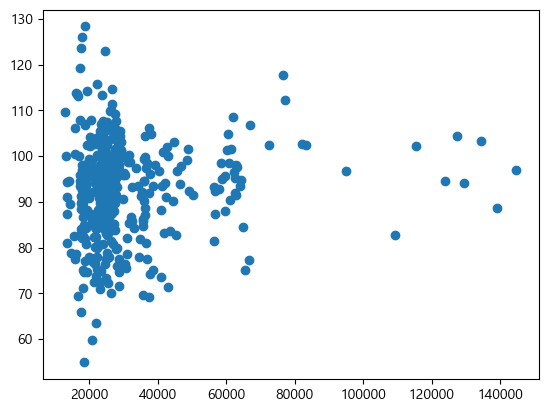

In [94]:
plt.scatter(data = data, x="avg_ticket", y="survival_rate_1y")

In [ ]:
data.corr(method="pearson") # 거의 상관 없음

,avg_ticket,survival_rate_1y
avg_ticket,1.000000,0.099797
survival_rate_1y,0.099797,1.000000


In [96]:
data.corr(method="spearman")

,avg_ticket,survival_rate_1y
avg_ticket,1.000000,0.105148
survival_rate_1y,0.105148,1.000000


In [97]:
data.corr(method="kendall")

,avg_ticket,survival_rate_1y
avg_ticket,1.000000,0.071721
survival_rate_1y,0.071721,1.000000


**상관관계 요약**
- 객단가와 신규점포 잔존율은 거의 상관이 없는 수준으로 확인됨.

**가설**
- 귀무가설(H0): 객단가와 신규점포 잔존율은 상관이 없다.
- 대립가설(H1): 객단가와 신규점포 잔존율은 양의 상관이 있다.

In [98]:
r, p_value = stats.pearsonr(data['avg_ticket'], data['survival_rate_1y'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.0998
p-value: 0.0461


In [99]:
r, p_value = stats.spearmanr(data['avg_ticket'], data['survival_rate_1y'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.1051
p-value: 0.0355


**검정 결과 및 해석**
- p-value가 유의수준 0.05 미만이므로 대립가설을 채택한다.
- 통계적으로 유의한 양의 상관은 확인되지만, 상관계수의 크기가 매우 작아 객단가만으로 신규점포 잔존율을 설명하기는 어렵다.

## 2. 신규기업 수와 폐업 점포 수

In [100]:
data_corp = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"new_corp_cnt": "sum", "close_cnt": "sum"})

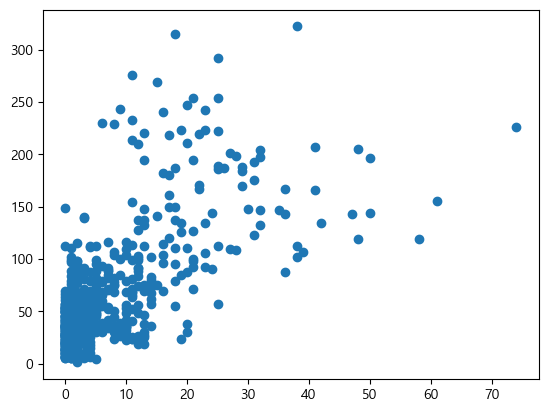

In [101]:
plt.scatter(data = data_corp, x="new_corp_cnt", y="close_cnt")

In [102]:
data_corp.corr(method="pearson")

,new_corp_cnt,close_cnt
new_corp_cnt,1.000000,0.667455
close_cnt,0.667455,1.000000


In [103]:
data_corp.corr(method="spearman")

,new_corp_cnt,close_cnt
new_corp_cnt,1.000000,0.613896
close_cnt,0.613896,1.000000


In [104]:
data_corp.corr(method="kendall")

,new_corp_cnt,close_cnt
new_corp_cnt,1.000000,0.455318
close_cnt,0.455318,1.000000


**상관관계 요약**
- 신규기업 수와 폐업 점포 수는 중간 정도의 양의 상관을 보인다.

**가설**
- 귀무가설(H0): 신규기업 수와 폐업 점포 수는 상관이 없다.
- 대립가설(H1): 신규기업 수와 폐업 점포 수는 양의 상관이 있다.

In [105]:
r, p_value = stats.pearsonr(data_corp['new_corp_cnt'], data_corp['close_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.6675
p-value: 0.0000


In [106]:
r, p_value = stats.spearmanr(data_corp['new_corp_cnt'], data_corp['close_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.6139
p-value: 0.0000


**검정 결과 및 해석**
- p-value가 유의수준 0.05 미만이므로 대립가설을 채택한다.
- 신규기업 수가 증가하는 구간에서 폐업 점포 수도 함께 증가하는 경향이 확인된다.

## 3. 신규기업 수와 프랜차이즈 수

In [107]:
data_fran = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"new_corp_cnt": "sum", "franchise_cnt": "sum"})

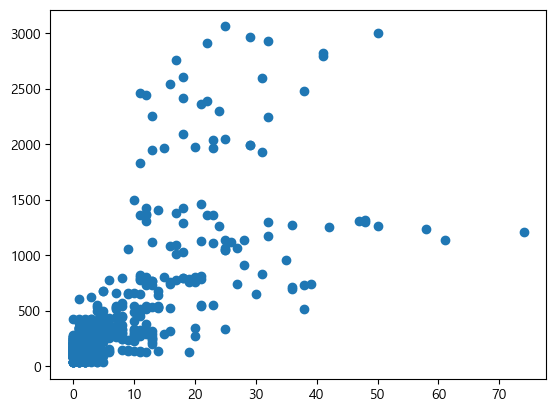

In [108]:
plt.scatter(data = data_fran, x="new_corp_cnt", y="franchise_cnt")

In [109]:
data_fran.corr(method="pearson")

,new_corp_cnt,franchise_cnt
new_corp_cnt,1.000000,0.705645
franchise_cnt,0.705645,1.000000


In [110]:
data_fran.corr(method="spearman")

,new_corp_cnt,franchise_cnt
new_corp_cnt,1.000000,0.729212
franchise_cnt,0.729212,1.000000


In [111]:
data_fran.corr(method="kendall")

,new_corp_cnt,franchise_cnt
new_corp_cnt,1.00000,0.55546
franchise_cnt,0.55546,1.00000


**상관관계 요약**
- 신규기업 수와 프랜차이즈 수는 중간 정도의 양의 상관을 보인다.

**가설**
- 귀무가설(H0): 신규기업 수와 프랜차이즈 수는 상관이 없다.
- 대립가설(H1): 신규기업 수와 프랜차이즈 수는 양의 상관이 있다.

In [113]:
r, p_value = stats.pearsonr(data_fran['new_corp_cnt'], data_fran['franchise_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.7056
p-value: 0.0000


In [ ]:
r, p_value = stats.spearmanr(data_fran['new_corp_cnt'], data_fran['franchise_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.7292
p-value: 0.0000


**검정 결과 및 해석**
- p-value가 유의수준 0.05 미만이므로 대립가설을 채택한다.
- 신규기업 수가 증가하는 구간에서 프랜차이즈 수 역시 증가하는 경향이 확인된다.

## 4. 단순 통과인구와 유동인구/체류시간

**가설**
- 귀무가설(H0): 유동인구가 증가하고 체류시간이 감소한 동의 단순 통과인구 비율은 그렇지 않은 동과 차이가 없다.
- 대립가설(H1): 유동인구는 증가했지만 체류시간이 감소한 동은 그렇지 않은 동보다 단순 통과인구 비율이 높다.

**변수 정의**
- `external_inflow`: 외부유입 인구(출발지: 성남시 외 지역, 도착지: 성남시)
- 단순 통과인구: 체류시간 `duration`이 60분 이하인 유입인구

In [5]:
con = duckdb.connect()

path = file_path + '/t26_duration_raw_selected.parquet'

con.execute(f"""
select *
from read_parquet('{path}')
limit 1
""").fetchdf()

,source_row_id,etl_ymd,dow,d_time_cd,gu,adm_dong_nm,adm_dong_cd,duration,cnt
0,1,2023-01-30,월,11,성남시 분당구,정자1동,41135550,180.0,3.71


In [6]:
# 단순 통과인구 수
df_pass = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        sum(cnt) as pass_cnt
    from read_parquet('{path}')
    where duration <= 60
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [7]:
# 전체 유입인구 수
df_all = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        sum(cnt) as inflow_cnt
    from read_parquet('{path}')
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [8]:
# 분기별 행정동별 단순 통과인구 비율
pass_ratio = con.execute(f"""
    select 
        p.quarter,
        p.gu,
        p.adm_dong_nm,
        p.pass_cnt,
        a.inflow_cnt,
        (p.pass_cnt / nullif(a.inflow_cnt, 0)) * 100 as pass_ratio_pct
    from df_pass as p
    left join df_all as a
    on p.adm_dong_nm = a.adm_dong_nm
    and p.gu = a.gu
    and p.quarter = a.quarter
""").fetchdf()

In [9]:
pass_ratio.head(1)

,quarter,gu,adm_dong_nm,pass_cnt,inflow_cnt,pass_ratio_pct
0,2023Q1,성남시 수정구,복정동,254096.76,1508694.92,16.842157


In [10]:
df.head(1)

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,close_cnt,open_rate,close_rate,franchise_ratio,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,77.0,1.687408,1.62413,4.893482,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624


In [15]:
duration = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        median(duration) as duration_m,
    from read_parquet('{path}')
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [ ]:
duration['q_idx'] = duration.groupby('adm_dong_nm').cumcount()  # 0,1,2,...

slopes = (duration.groupby('adm_dong_nm')
              .apply(lambda g: np.polyfit(g['q_idx'], g['dur_median'], 1)[0]))

dur_down_dongs = slopes[slopes < 0].index   # 기울기 음수 = 감소 추세

In [16]:
pivot = duration.pivot(index='adm_dong_nm', columns='quarter', values='duration_m')
pivot

quarter,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
adm_dong_nm,,,,,,,,,,,,
고등동,180.0,180.0,180.0,180.0,180.00,180.0,180.0,180.0,210.0,210.0,210.0,210.0
구미1동,150.0,150.0,150.0,150.0,150.00,150.0,150.0,150.0,180.0,180.0,180.0,180.0
구미동,180.0,180.0,180.0,180.0,180.00,180.0,180.0,180.0,180.0,180.0,180.0,180.0
금곡동,180.0,150.0,150.0,150.0,170.12,150.0,150.0,150.0,180.0,180.0,180.0,180.0
금광1동,180.0,180.0,180.0,180.0,180.00,150.0,150.0,150.0,180.0,180.0,180.0,180.0
금광2동,180.0,180.0,180.0,180.0,180.00,180.0,180.0,180.0,210.0,210.0,210.0,210.0
단대동,180.0,180.0,180.0,180.0,180.00,180.0,180.0,180.0,210.0,210.0,210.0,210.0
도촌동,180.0,180.0,180.0,180.0,180.00,180.0,180.0,180.0,210.0,180.0,210.0,210.0
백현동,180.0,180.0,180.0,180.0,180.00,150.0,180.0,180.0,180.0,180.0,180.0,180.0


In [ ]:

first_q, last_q = pivot.columns.min(), pivot.columns.max()
dur_down_dongs = pivot.index[pivot[last_q] < pivot[first_q]]

In [ ]:
# 유동인구 증가 + 체류시간 감소한 동
pivot_pop = df.pivot_table(index='adm_dong_nm', columns='base_quarter', 
                            values='floating_pop', aggfunc='sum')
pivot_dur = df_d.pivot_table(index='adm_dong_nm', columns='base_quarter', 
                              values='duration', aggfunc='median')

first_q, last_q = '2023Q1', '2025Q2'  # 실제 데이터에 맞게 조정

pop_up   = pivot_pop[last_q] > pivot_pop[first_q]   # 유동인구 증가
dur_down = pivot_dur[last_q] < pivot_dur[first_q]   # 체류시간 감소

group_A = (pop_up & dur_down)   # 조건 만족 동

## 5. 유동인구와 매출건수

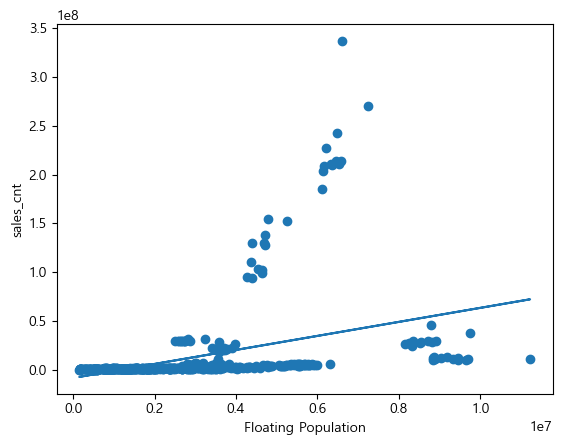

In [8]:
data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "sum", "sales_cnt": "sum"})

x = data["floating_pop"]
y = data["sales_cnt"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("sales_cnt")
plt.show()

In [9]:
r, p_value = stats.pearsonr(data["floating_pop"], data["sales_cnt"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.3987
p-value: 0.0000


In [11]:
r, p_value = stats.spearmanr(data["floating_pop"], data["sales_cnt"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.8333
p-value: 0.0000


## 6. 유동인구와 매출금액

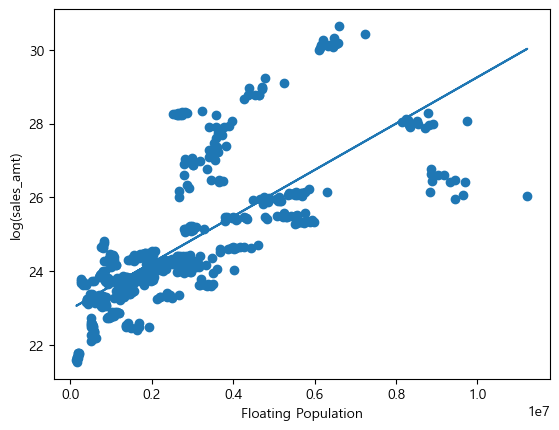

In [12]:
df["log_sales"] = np.log1p(df["sales_amt"])

data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "mean", "log_sales": "mean"})

x = data["floating_pop"]
y = data["log_sales"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("log(sales_amt)")
plt.show()

**가설**
- 귀무가설(H0): 유동인구와 매출금액은 상관이 없다.
- 대립가설(H1): 유동인구와 매출금액은 양의 상관이 있다.

In [13]:
r, p_value = stats.pearsonr(data["floating_pop"], data["log_sales"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.7291
p-value: 0.0000


In [15]:
r, p_value = stats.spearmanr(data["floating_pop"], data["log_sales"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.8006
p-value: 0.0000


**상관관계 요약**
- 유동인구와 매출금액은 강한 양의 관계를 보인다.

## 7. 유동인구와 객단가

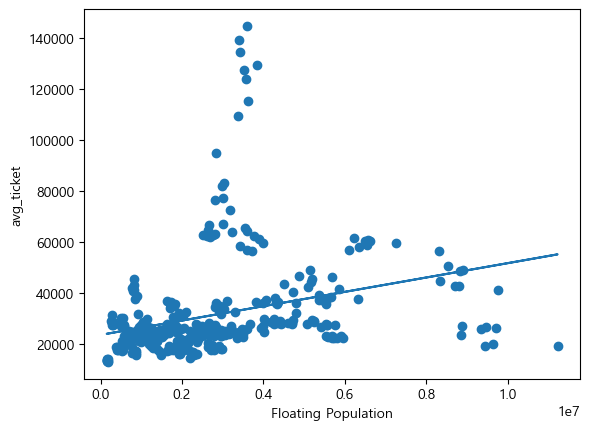

In [ ]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]
data = df_24_25.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "mean", "avg_ticket": "mean"})

plt.scatter(data = data, x="floating_pop", y="avg_ticket")

# x, y 값 추출
x = data["floating_pop"]
y = data["avg_ticket"]

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("avg_ticket")
plt.show()

In [134]:
data.corr(method="pearson")

,avg_ticket,floating_pop
avg_ticket,1.000000,0.301855
floating_pop,0.301855,1.000000


In [135]:
data.corr(method="spearman")

,avg_ticket,floating_pop
avg_ticket,1.000000,0.472256
floating_pop,0.472256,1.000000


In [136]:
data.corr(method="kendall")

,avg_ticket,floating_pop
avg_ticket,1.000000,0.316667
floating_pop,0.316667,1.000000


**상관관계 요약**
- 유동인구와 객단가는 약한 수준에서 중간 수준 사이의 양의 상관을 보인다.

**가설**
- 귀무가설(H0): 유동인구와 객단가는 상관이 없다.
- 대립가설(H1): 유동인구와 객단가는 양의 상관이 있다.

In [138]:
r, p_value = stats.pearsonr(data["floating_pop"], data["avg_ticket"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.3019
p-value: 0.0000


In [139]:
r, p_value = stats.spearmanr(data["floating_pop"], data["avg_ticket"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.4723
p-value: 0.0000


**검정 결과 및 해석**
- p-value가 유의수준 0.05 미만이므로 대립가설을 채택한다.
- 유동인구와 객단가는 통계적으로 유의한 양의 상관관계가 있으나, 상관 정도는 강하지 않다.
- 선형 관계보다는 값이 커질수록 함께 증가하는 비선형/단조 관계가 더 뚜렷하게 나타난다.